# Word Embeddings Visualization
## Demonstrating Semantic Similarity: Dog, Cat, and spaceship

This notebook demonstrates how word embeddings capture semantic meaning by showing that 'dog' and 'cat' are closer to each other than to 'spaceship'.

In [2]:
# Install required packages
# Note: If you get numpy version warnings, you can ignore them or run:
# !pip install numpy>=2.0.0 --force-reinstall
!pip install gensim matplotlib scikit-learn scipy

In [3]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Load Pre-trained Word Embeddings
We'll use Google's pre-trained Word2Vec model trained on Google News corpus.

In [4]:
# Load pre-trained Word2Vec model (this may take a minute)
print("Loading Word2Vec model...")
model = api.load('word2vec-google-news-300')
print("Model loaded successfully!")

Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully!


## Get Word Embeddings

In [10]:
# Define our words
words = ['dog', 'cat', 'spaceship']

# Get embeddings for each word
embeddings = {}
for word in words:
    embeddings[word] = model[word]
    print(f"Embedding for '{word}': shape {embeddings[word].shape}")

# Show first 10 dimensions of each embedding
print("\nFirst 10 dimensions:")
for word in words:
    print(f"{word}: {embeddings[word][:10]}")

Embedding for 'dog': shape (300,)
Embedding for 'cat': shape (300,)
Embedding for 'spaceship': shape (300,)

First 10 dimensions:
dog: [ 0.05126953 -0.02233887 -0.17285156  0.16113281 -0.08447266  0.05737305
  0.05859375 -0.08251953 -0.01538086 -0.06347656]
cat: [ 0.0123291   0.20410156 -0.28515625  0.21679688  0.11816406  0.08300781
  0.04980469 -0.00952148  0.22070312 -0.12597656]
spaceship: [ 0.21777344  0.09375    -0.00878906 -0.19824219 -0.09082031 -0.12695312
  0.1796875  -0.1953125   0.31640625 -0.20800781]


## Calculate Cosine Similarity
Cosine similarity measures how similar two vectors are (1 = identical, 0 = orthogonal, -1 = opposite)

In [13]:
from scipy.spatial.distance import cosine

# Calculate similarities
print("Cosine Similarities:")
print(f"dog ↔ cat: {1 - cosine(embeddings['dog'], embeddings['cat']):.4f}")
print(f"dog ↔ spaceship: {1 - cosine(embeddings['dog'], embeddings['spaceship']):.4f}")
print(f"cat ↔ spaceship: {1 - cosine(embeddings['cat'], embeddings['spaceship']):.4f}")

print("\nNote: Higher similarity means words are more semantically related.")

Cosine Similarities:
dog ↔ cat: 0.7609
dog ↔ spaceship: 0.1100
cat ↔ spaceship: 0.1381

Note: Higher similarity means words are more semantically related.


## Visualize Embeddings in 2D Space
We'll reduce the 300-dimensional embeddings to 2D using PCA for visualization.

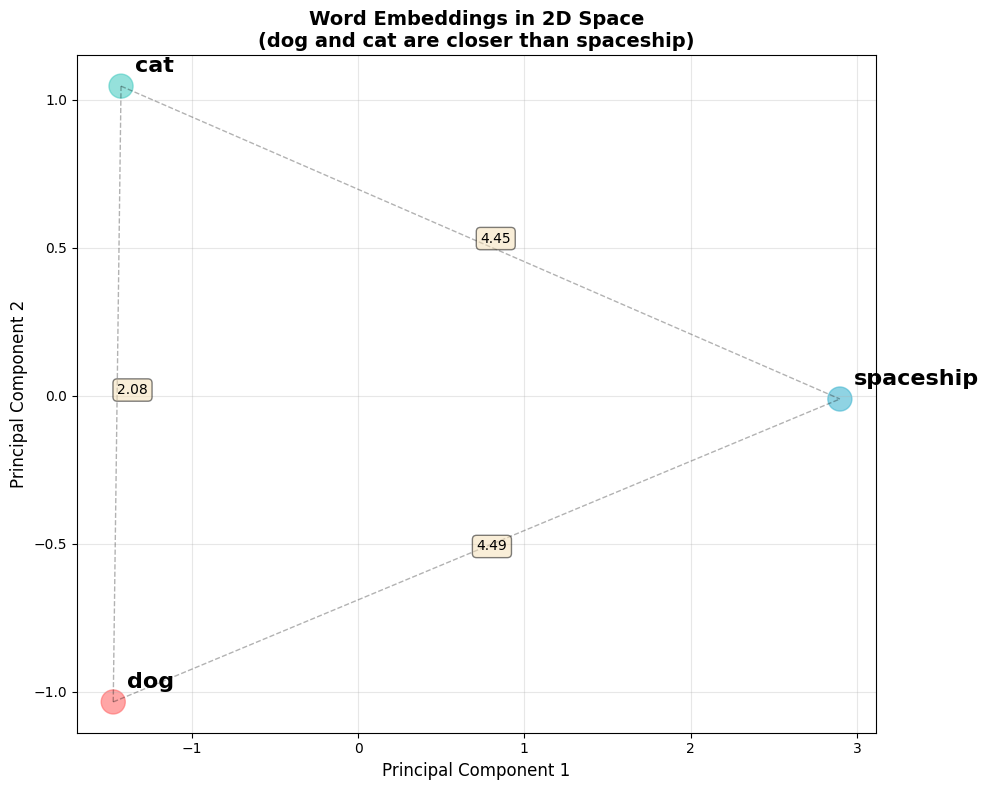

Explained variance by 2 components: 100.00%


In [21]:
# Prepare data for dimensionality reduction
embedding_matrix = np.array([embeddings[word] for word in words])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embedding_matrix)

# Create the plot
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=300, alpha=0.6, c=['#FF6B6B', '#4ECDC4', '#45B7D1'])

# Add labels
for i, word in enumerate(words):
    plt.annotate(word, 
                xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=16,
                fontweight='bold')

# Draw lines connecting the words with distance labels
from scipy.spatial.distance import euclidean
for i in range(len(words)):
    for j in range(i+1, len(words)):
        mid_x = (embeddings_2d[i, 0] + embeddings_2d[j, 0]) / 2
        mid_y = (embeddings_2d[i, 1] + embeddings_2d[j, 1]) / 2
        dist = euclidean(embeddings_2d[i], embeddings_2d[j])
        plt.plot([embeddings_2d[i, 0], embeddings_2d[j, 0]], 
                [embeddings_2d[i, 1], embeddings_2d[j, 1]], 
                'k--', alpha=0.3, linewidth=1)
        plt.text(mid_x, mid_y, f'{dist:.2f}', fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title('Word Embeddings in 2D Space\n(dog and cat are closer than spaceship)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('word_embeddings_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Explained variance by 2 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 3D Visualization
Let's visualize in 3D space to better see the relationships!

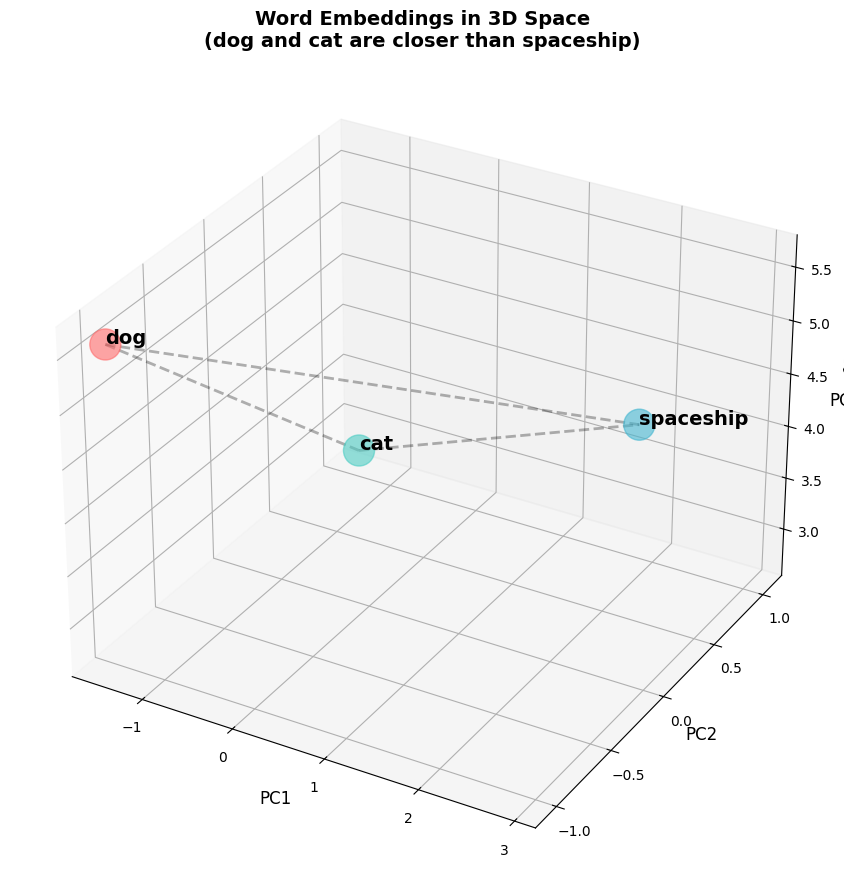


Euclidean Distances in 3D:
dog ↔ cat: 2.0815
dog ↔ spaceship: 4.4877
cat ↔ spaceship: 4.4500

Explained variance by 3 components: 100.00%

✓ In 3D, dog and cat are clearly closer to each other than to spaceship!


In [22]:
# Reduce to 3D using PCA
pca_3d = PCA(n_components=3)
embeddings_3d = pca_3d.fit_transform(embedding_matrix)

# Create 3D plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], 
           s=500, alpha=0.6, c=colors)

# Add labels
for i, word in enumerate(words):
    ax.text(embeddings_3d[i, 0], embeddings_3d[i, 1], embeddings_3d[i, 2], 
            word, fontsize=14, fontweight='bold')

# Draw lines connecting the words
for i in range(len(words)):
    for j in range(i+1, len(words)):
        ax.plot([embeddings_3d[i, 0], embeddings_3d[j, 0]], 
                [embeddings_3d[i, 1], embeddings_3d[j, 1]],
                [embeddings_3d[i, 2], embeddings_3d[j, 2]],
                'k--', alpha=0.3, linewidth=2)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title('Word Embeddings in 3D Space\n(dog and cat are closer than spaceship)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('word_embeddings_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate 3D distances
print("\nEuclidean Distances in 3D:")
dist_dog_cat_3d = euclidean(embeddings_3d[0], embeddings_3d[1])
dist_dog_car_3d = euclidean(embeddings_3d[0], embeddings_3d[2])
dist_cat_car_3d = euclidean(embeddings_3d[1], embeddings_3d[2])

print(f"dog ↔ cat: {dist_dog_cat_3d:.4f}")
print(f"dog ↔ spaceship: {dist_dog_car_3d:.4f}")
print(f"cat ↔ spaceship: {dist_cat_car_3d:.4f}")

print(f"\nExplained variance by 3 components: {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")
print("\n✓ In 3D, dog and cat are clearly closer to each other than to spaceship!")

## Calculate Euclidean Distances in 2D Space

In [19]:
from scipy.spatial.distance import euclidean

print("Euclidean Distances in 2D:")
dist_dog_cat = euclidean(embeddings_2d[0], embeddings_2d[1])
dist_dog_car = euclidean(embeddings_2d[0], embeddings_2d[2])
dist_cat_car = euclidean(embeddings_2d[1], embeddings_2d[2])

print(f"dog ↔ cat: {dist_dog_cat:.4f}")
print(f"dog ↔ spaceship: {dist_dog_car:.4f}")
print(f"cat ↔ spaceship: {dist_cat_car:.4f}")

print("\n✓ dog and cat are closer to each other than to spaceship!")

Euclidean Distances in 2D:
dog ↔ cat: 2.0815
dog ↔ spaceship: 4.4877
cat ↔ spaceship: 4.4500

✓ dog and cat are closer to each other than to spaceship!


## Bonus: Find Similar Words
Let's see what other words are similar to our three words.

In [18]:
for word in words:
    print(f"\nWords most similar to '{word}':")
    similar_words = model.most_similar(word, topn=5)
    for similar_word, similarity in similar_words:
        print(f"  {similar_word}: {similarity:.4f}")


Words most similar to 'dog':
  dogs: 0.8680
  puppy: 0.8106
  pit_bull: 0.7804
  pooch: 0.7627
  cat: 0.7609

Words most similar to 'cat':
  cats: 0.8099
  dog: 0.7609
  kitten: 0.7465
  feline: 0.7326
  beagle: 0.7151

Words most similar to 'spaceship':
  spacecraft: 0.7121
  spaceships: 0.6988
  Virgin_Galactic_unveils: 0.6382
  spacecrafts: 0.6363
  outer_space: 0.6342
